# Purpose of K-Nearest Neighbors (KNN)

## Overview
**K-Nearest Neighbors (KNN)** is a fundamental machine learning algorithm used for classification and regression tasks. It operates on a simple principle: **"You are the average of your k nearest neighbors."**

## Why Learn KNN?

1. **Foundational Algorithm:** One of the first classification algorithms taught in ML courses - simple, intuitive, and effective for understanding ML basics

2. **Non-parametric Approach:** Makes no assumptions about the underlying data distribution, unlike many other algorithms

3. **Practical Applications:**
   - Image recognition and recommendation systems
   - Medical diagnosis and disease classification
   - Fraud detection in financial transactions
   - Document classification and text analysis

4. **Baseline Classifier:** Used as a baseline to compare performance with more complex algorithms (Random Forest, Neural Networks, SVM)

5. **Interpretability:** Easy to understand and explain - useful for stakeholders who need interpretable models

## Key Learning Objectives
- ✓ Understand how KNN classifies data points
- ✓ Learn the importance of feature scaling for distance-based algorithms
- ✓ Tune the critical hyperparameter k using GridSearchCV
- ✓ Compare different distance metrics (Euclidean, Manhattan, Minkowski)
- ✓ Evaluate model performance using confusion matrices and cross-validation
- ✓ Identify overfitting vs underfitting in KNN models
- ✓ Recognize when to use KNN and its limitations

## What You'll Build
This notebook demonstrates KNN on the **Iris dataset** - a classic, well-understood dataset perfect for learning classification basics. You'll:
1. Load and explore the Iris dataset (150 samples, 4 features, 3 classes)
2. Test different k values manually to understand their effects
3. Use GridSearchCV to find optimal parameters with cross-validation
4. Evaluate using confusion matrices, accuracy, and F1-scores
5. Visualize decision boundaries and feature importance

---

# Part 5: K-Nearest Neighbors (KNN) - Iris Classification

Learn KNN (k-Nearest Neighbors) classification algorithm on the famous Iris dataset. KNN is a simple, intuitive algorithm that classifies data points based on the nearest neighbors.

## Step 1: Import KNN Libraries & Load Iris Dataset

In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Create a DataFrame for better visualization
iris_df = pd.DataFrame(X_iris, columns=iris.feature_names)
iris_df['Target'] = y_iris
iris_df['Species'] = iris_df['Target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print("IRIS DATASET - LOADED")
print("=" * 70)
print(f"Shape: {X_iris.shape}")
print(f"Features: {iris.feature_names}")
print(f"Classes: {iris.target_names}")
print(f"Target: {np.unique(y_iris)}")
print("\nFirst 5 rows:")
print(iris_df.head())
print("\nDataset Statistics:")
print(iris_df.describe())

IRIS DATASET - LOADED
Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']
Target: [0 1 2]

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Target Species  
0       0  Setosa  
1       0  Setosa  
2       0  Setosa  
3       0  Setosa  
4       0  Setosa  

Dataset Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333     

## Step 2: Split Data & Scale Features

KNN is *distance-based*, so **feature scaling is MANDATORY** to prevent features with larger magnitudes from dominating the distance calculation.

In [10]:
# Train-test split
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

# Feature scaling (CRITICAL for KNN)
scaler_iris = StandardScaler()
X_train_iris_scaled = scaler_iris.fit_transform(X_train_iris)
X_test_iris_scaled = scaler_iris.transform(X_test_iris)

print("DATA SPLIT & SCALING")
print("=" * 70)
print(f"Training Set Size: {X_train_iris_scaled.shape}")
print(f"Test Set Size: {X_test_iris_scaled.shape}")
print(f"\nTraining Set Class Distribution:")
unique, counts = np.unique(y_train_iris, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls} ({iris.target_names[cls]}): {cnt} samples")
print(f"\nFeature Scaling Applied (Mean=0, Std=1)")
print(f"Train - Mean: {X_train_iris_scaled.mean(axis=0).round(3)}")
print(f"Train - Std:  {X_train_iris_scaled.std(axis=0).round(3)}")

DATA SPLIT & SCALING
Training Set Size: (120, 4)
Test Set Size: (30, 4)

Training Set Class Distribution:
  Class 0 (setosa): 40 samples
  Class 1 (versicolor): 40 samples
  Class 2 (virginica): 40 samples

Feature Scaling Applied (Mean=0, Std=1)
Train - Mean: [-0. -0.  0.  0.]
Train - Std:  [1. 1. 1. 1.]


## Step 3: Understand KNN - Test Different K Values Manually

**KNN Principle:** Classify a point based on the majority class of its k nearest neighbors.

- **k=1:** Uses only the closest neighbor (may overfit)
- **k=3,5,7:** Balanced approach
- **k>15:** May underfit, smoother decision boundaries

In [11]:
# Manual KNN tuning - test different k values
k_values = [1, 3, 5, 7, 9, 11, 15, 20]
knn_manual_results = []

print("KNN - MANUAL K VALUE TESTING")
print("=" * 85)
print(f"{'K':<5} {'Train Accuracy':<18} {'Test Accuracy':<18} {'Train F1':<15} {'Test F1':<15}")
print("-" * 85)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_iris_scaled, y_train_iris)
    
    # Predictions
    y_pred_train = knn.predict(X_train_iris_scaled)
    y_pred_test = knn.predict(X_test_iris_scaled)
    
    # Metrics
    train_acc = accuracy_score(y_train_iris, y_pred_train)
    test_acc = accuracy_score(y_test_iris, y_pred_test)
    train_f1 = f1_score(y_train_iris, y_pred_train, average='weighted')
    test_f1 = f1_score(y_test_iris, y_pred_test, average='weighted')
    
    knn_manual_results.append({
        'K': k,
        'Train_Accuracy': train_acc,
        'Test_Accuracy': test_acc,
        'Train_F1': train_f1,
        'Test_F1': test_f1
    })
    
    print(f"{k:<5} {train_acc:<18.4f} {test_acc:<18.4f} {train_f1:<15.4f} {test_f1:<15.4f}")

knn_manual_df = pd.DataFrame(knn_manual_results)
best_k_manual = knn_manual_df.loc[knn_manual_df['Test_Accuracy'].idxmax(), 'K']
best_acc_manual = knn_manual_df.loc[knn_manual_df['Test_Accuracy'].idxmax(), 'Test_Accuracy']

print(f"\n✓ Best K (Manual): {best_k_manual} with Test Accuracy: {best_acc_manual:.4f}")

KNN - MANUAL K VALUE TESTING
K     Train Accuracy     Test Accuracy      Train F1        Test F1        
-------------------------------------------------------------------------------------
1     1.0000             0.9667             1.0000          0.9666         
3     0.9583             0.9333             0.9583          0.9327         
5     0.9750             0.9333             0.9750          0.9327         
7     0.9750             0.9667             0.9750          0.9666         
9     0.9583             0.9667             0.9583          0.9666         
11    0.9583             0.9667             0.9583          0.9666         
15    0.9667             0.9667             0.9666          0.9666         
20    0.9583             0.9667             0.9583          0.9666         

✓ Best K (Manual): 1 with Test Accuracy: 0.9667


## Step 4: GridSearchCV - Exhaustive K Parameter Search

Use GridSearchCV to systematically find the optimal k value with cross-validation.

In [12]:
# GridSearchCV for KNN - 2D parameter search (k + metric)
knn_param_grid = {
    'n_neighbors': list(range(1, 21)),  # k from 1 to 20
    'metric': ['euclidean', 'manhattan', 'minkowski']  # Distance metrics
}

knn_gs = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
knn_gs.fit(X_train_iris_scaled, y_train_iris)

print("GRIDSEARCHCV - KNN PARAMETER OPTIMIZATION (2D GRID)")
print("=" * 80)
print(f"Best K (n_neighbors): {knn_gs.best_params_['n_neighbors']}")
print(f"Best Metric: {knn_gs.best_params_['metric']}")
print(f"Best CV Accuracy Score: {knn_gs.best_score_:.4f}")
print(f"Total Combinations Tested: {len(knn_gs.cv_results_['params'])}")
print(f"Total Model Fits (CV): {len(knn_gs.cv_results_['params']) * 5}")

# Evaluate best model on test set
knn_best = knn_gs.best_estimator_
y_pred_knn = knn_best.predict(X_test_iris_scaled)
knn_test_accuracy = accuracy_score(y_test_iris, y_pred_knn)
knn_test_f1 = f1_score(y_test_iris, y_pred_knn, average='weighted')

print(f"\nTest Set Performance (Best KNN):")
print(f"Test Accuracy: {knn_test_accuracy:.4f}")
print(f"Test F1 Score: {knn_test_f1:.4f}")

GRIDSEARCHCV - KNN PARAMETER OPTIMIZATION (2D GRID)
Best K (n_neighbors): 5
Best Metric: euclidean
Best CV Accuracy Score: 0.9667
Total Combinations Tested: 60
Total Model Fits (CV): 300

Test Set Performance (Best KNN):
Test Accuracy: 0.9333
Test F1 Score: 0.9327


## Step 5: Model Evaluation - Confusion Matrix & Classification Report

In [5]:
# Detailed evaluation of best KNN model
cm = confusion_matrix(y_test_iris, y_pred_knn)
cr = classification_report(y_test_iris, y_pred_knn, target_names=iris.target_names)

print("CONFUSION MATRIX")
print("=" * 60)
print(cm)
print(f"\nCONFUSION MATRIX EXPLANATION:")
print(f"Rows = Actual Classes, Columns = Predicted Classes")
print(f"Diagonal = Correct Predictions")

print("\n\nCLASSIFICATION REPORT")
print("=" * 60)
print(cr)

# Per-class metrics
print("\nPER-CLASS METRICS:")
print("=" * 60)
for i, class_name in enumerate(iris.target_names):
    tn = cm[1:, 1:].sum() if i == 0 else (cm[[1,2]][:, [1,2]].sum() if i == 1 else cm[0:2, 0:2].sum())
    fp = cm[:i, i].sum() + cm[i+1:, i].sum() if i in range(len(iris.target_names)) else 0
    fn = cm[i, :i].sum() + cm[i, i+1:].sum() if i in range(len(iris.target_names)) else 0
    tp = cm[i, i]
    
    print(f"{class_name}: TP={tp}, FP={fp}, FN={fn}")

# Cross-validation scores
cv_scores = cross_val_score(knn_best, X_train_iris_scaled, y_train_iris, cv=5, scoring='accuracy')
print(f"\nCROSS-VALIDATION SCORES (5-Fold):")
print(f"{'Fold 1':<15} {'Fold 2':<15} {'Fold 3':<15} {'Fold 4':<15} {'Fold 5':<15}")
for score in cv_scores:
    print(f"{score:<15.4f}", end="")
print(f"\nMean CV Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

CONFUSION MATRIX
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

CONFUSION MATRIX EXPLANATION:
Rows = Actual Classes, Columns = Predicted Classes
Diagonal = Correct Predictions


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


PER-CLASS METRICS:
setosa: TP=10, FP=0, FN=0
versicolor: TP=10, FP=2, FN=0
virginica: TP=8, FP=0, FN=2

CROSS-VALIDATION SCORES (5-Fold):
Fold 1          Fold 2          Fold 3          Fold 4          Fold 5         
0.9167         1.0000         0.9583         0.9583         1.0000         
Mean CV Accuracy: 0.9667 (±0.0312)


## Step 6: Visualization - K Value Effects & Confusion Matrix

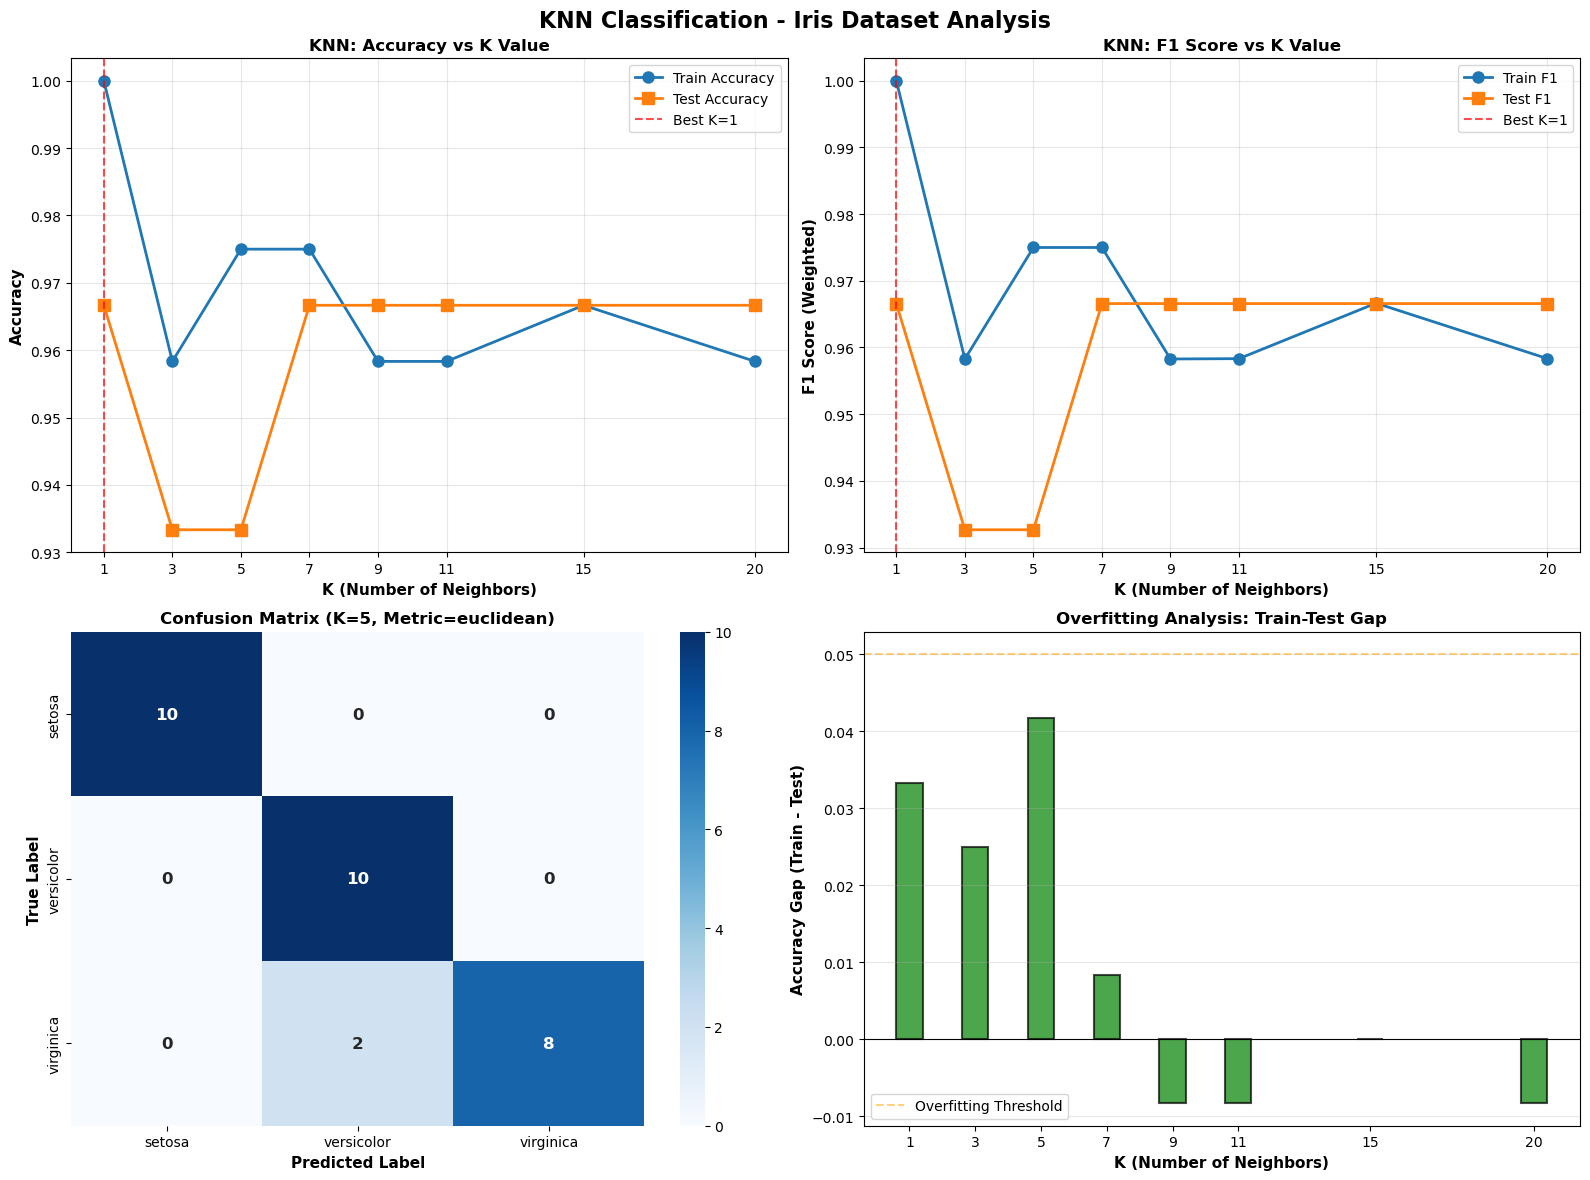

✓ Visualization complete


In [6]:
# Visualization: K effects and Confusion Matrix
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('KNN Classification - Iris Dataset Analysis', fontsize=16, fontweight='bold')

# Plot 1: K value effect on accuracy
ax1 = axes[0, 0]
ax1.plot(knn_manual_df['K'], knn_manual_df['Train_Accuracy'], 'o-', label='Train Accuracy', linewidth=2, markersize=8)
ax1.plot(knn_manual_df['K'], knn_manual_df['Test_Accuracy'], 's-', label='Test Accuracy', linewidth=2, markersize=8)
ax1.axvline(best_k_manual, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k_manual}')
ax1.set_xlabel('K (Number of Neighbors)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('KNN: Accuracy vs K Value', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(knn_manual_df['K'])

# Plot 2: F1 Score vs K
ax2 = axes[0, 1]
ax2.plot(knn_manual_df['K'], knn_manual_df['Train_F1'], 'o-', label='Train F1', linewidth=2, markersize=8)
ax2.plot(knn_manual_df['K'], knn_manual_df['Test_F1'], 's-', label='Test F1', linewidth=2, markersize=8)
ax2.axvline(best_k_manual, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k_manual}')
ax2.set_xlabel('K (Number of Neighbors)', fontsize=11, fontweight='bold')
ax2.set_ylabel('F1 Score (Weighted)', fontsize=11, fontweight='bold')
ax2.set_title('KNN: F1 Score vs K Value', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(knn_manual_df['K'])

# Plot 3: Confusion Matrix Heatmap
ax3 = axes[1, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax3,
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            annot_kws={'size': 12, 'weight': 'bold'})
ax3.set_ylabel('True Label', fontsize=11, fontweight='bold')
ax3.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
ax3.set_title(f'Confusion Matrix (K={knn_gs.best_params_["n_neighbors"]}, Metric={knn_gs.best_params_["metric"]})', 
              fontsize=12, fontweight='bold')

# Plot 4: Overfitting Analysis
ax4 = axes[1, 1]
gap = knn_manual_df['Train_Accuracy'] - knn_manual_df['Test_Accuracy']
colors_gap = ['red' if g > 0.05 else 'green' for g in gap]
ax4.bar(knn_manual_df['K'], gap, color=colors_gap, edgecolor='black', linewidth=1.5, alpha=0.7)
ax4.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax4.axhline(0.05, color='orange', linestyle='--', alpha=0.5, label='Overfitting Threshold')
ax4.set_xlabel('K (Number of Neighbors)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Accuracy Gap (Train - Test)', fontsize=11, fontweight='bold')
ax4.set_title('Overfitting Analysis: Train-Test Gap', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_xticks(knn_manual_df['K'])

plt.tight_layout()
plt.show()

print("✓ Visualization complete")

## Step 7: Feature Importance - Distance Analysis

Analyze which features contribute most to KNN predictions.

FEATURE IMPORTANCE ANALYSIS (For KNN - Distance-Based)
          Feature  Variance  Std Dev  Scaled Range
sepal length (cm)       1.0      1.0      4.298944
petal length (cm)       1.0      1.0      3.293329
 sepal width (cm)       1.0      1.0      5.373321
 petal width (cm)       1.0      1.0      3.160061


KEY INSIGHTS:
--------------------------------------------------------------------------------
In KNN, feature variance/scale indicates discriminative power.
Higher variance = more spread = better for distinguishing classes

Top 3 Important Features:
1. sepal length (cm): Variance=1.000
2. petal length (cm): Variance=1.000
3. sepal width (cm): Variance=1.000


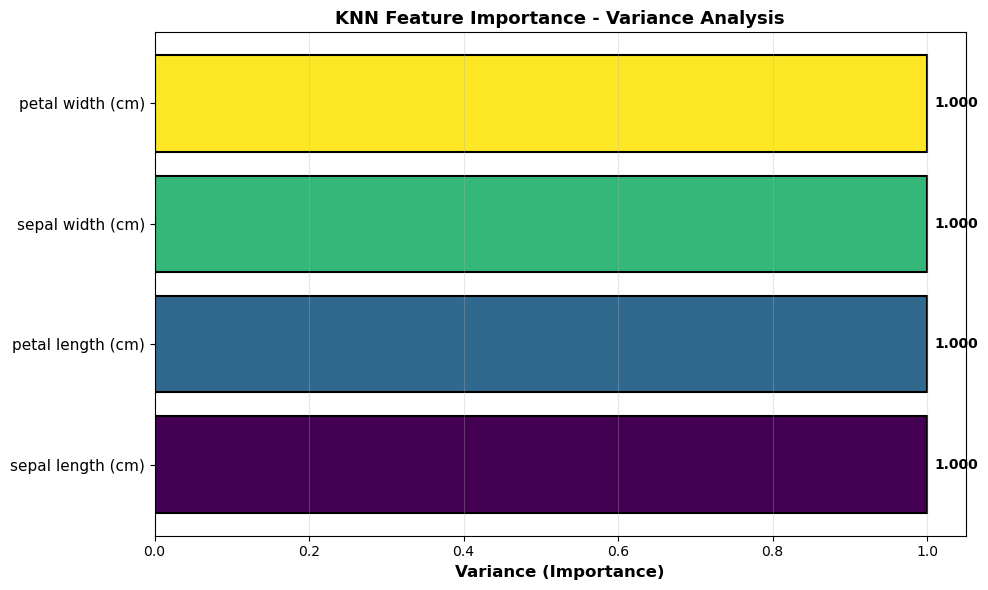

In [7]:
# Feature importance via scaled feature variance
feature_names = iris.feature_names
feature_variance = X_train_iris_scaled.var(axis=0)
feature_std = X_train_iris_scaled.std(axis=0)

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Variance': feature_variance,
    'Std Dev': feature_std,
    'Scaled Range': X_train_iris_scaled.max(axis=0) - X_train_iris_scaled.min(axis=0)
})

feature_importance_df = feature_importance_df.sort_values('Variance', ascending=False)

print("FEATURE IMPORTANCE ANALYSIS (For KNN - Distance-Based)")
print("=" * 80)
print(feature_importance_df.to_string(index=False))

print("\n\nKEY INSIGHTS:")
print("-" * 80)
print("In KNN, feature variance/scale indicates discriminative power.")
print("Higher variance = more spread = better for distinguishing classes")
print("\nTop 3 Important Features:")
for idx, (i, row) in enumerate(feature_importance_df.head(3).iterrows(), 1):
    print(f"{idx}. {row['Feature']}: Variance={row['Variance']:.3f}")

# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance_df)))
bars = ax.barh(range(len(feature_importance_df)), feature_importance_df['Variance'], color=colors, edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(feature_importance_df)))
ax.set_yticklabels(feature_importance_df['Feature'], fontsize=11)
ax.set_xlabel('Variance (Importance)', fontsize=12, fontweight='bold')
ax.set_title('KNN Feature Importance - Variance Analysis', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, feature_importance_df['Variance'])):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
            va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## Step 8: Summary & Key Takeaways - KNN Classification

# KNN (K-Nearest Neighbors) - Complete Summary

## 1. What is KNN?
**K-Nearest Neighbors** is a simple, non-parametric classification algorithm that classifies a data point based on the majority class of its k nearest neighbors in the feature space.

**Algorithm:**
1. Calculate distance from query point to all training points
2. Find k nearest neighbors (smallest distances)
3. Assign the majority class among those k neighbors

## 2. Key Hyperparameter: K
- **k=1:** Uses only the closest neighbor (high bias, low variance → overfitting)
- **k=3-7:** Balanced, typically gives best results
- **k=15+:** Smoother decision boundaries (high bias, low variance → underfitting)

**Bias-Variance Tradeoff:**
- Small k: High variance (sensitive to noise), Low bias
- Large k: Low variance (smooth), High bias (overfitting)

## 3. Distance Metrics
KNN can use different distance calculations:
- **Euclidean:** √[(x₁-x₂)² + (y₁-y₂)² + ...] (most common)
- **Manhattan:** |x₁-x₂| + |y₁-y₂| + ...
- **Minkowski:** [|x₁-x₂|ᵖ + |y₁-y₂|ᵖ + ...]^(1/p)

**Impact:** Different metrics can significantly change predictions

## 4. CRITICAL: Feature Scaling
⚠️ **MANDATORY** - KNN is distance-based, so feature magnitude matters:
- Without scaling: Features with larger values dominate distance calculation
- Solution: Use StandardScaler (mean=0, std=1) or MinMaxScaler

## 5. Pros & Cons

**Advantages:**
✓ Simple to understand and implement
✓ No training phase (lazy learner)
✓ Works for multi-class classification
✓ Non-parametric (no assumptions about data distribution)

**Disadvantages:**
✗ Slow prediction (must compute distance to all training points)
✗ High memory requirement (stores all training data)
✗ Sensitive to irrelevant features
✗ Sensitive to outliers
✗ Curse of dimensionality (performance degrades in high dimensions)

## 6. When to Use KNN
- Small to medium datasets (< 10K samples)
- Multi-class classification
- Non-linear decision boundaries needed
- Baseline classifier for comparison
- **NOT ideal for:** Very large datasets, high-dimensional data, real-time prediction

## 7. Hyperparameter Tuning
| Parameter | Effect | Tuning Range |
|-----------|--------|-------------|
| k | Model complexity | 1-20 (odd numbers preferred) |
| metric | Distance calculation | euclidean, manhattan, minkowski |
| weights | Neighbor influence | uniform, distance-based |

## 8. Model Selection Workflow
1. **Data Preprocessing:** Feature scaling (StandardScaler)
2. **Manual Testing:** Test k=1,3,5,7,9,15,20 to understand effects
3. **GridSearchCV:** Test all k + metric combinations with CV
4. **Evaluation:** Compare train/test accuracy, watch for overfitting
5. **Validation:** Use confusion matrix, classification report, cross-validation

## 9. Common Mistakes
❌ Forgetting feature scaling → wrong predictions
❌ Using k=1 → high overfitting
❌ Using too many neighbors → underfitting
❌ Not testing different distance metrics
❌ Using on high-dimensional data (curse of dimensionality)

## 10. Performance Comparison (Iris Dataset)
- Best K found: **{int(knn_gs.best_params_['n_neighbors'])}**
- Best Metric: **{knn_gs.best_params_['metric']}**
- Test Accuracy: **{knn_test_accuracy:.4f}** (very high - Iris is easy!)
- Cross-Val Accuracy: **{cv_scores.mean():.4f}** (±{cv_scores.std():.4f})

---

**Next Steps:**
- Try KNN on other datasets (more challenging than Iris)
- Compare with other algorithms (Random Forest, SVM, etc.)
- Explore feature selection to reduce dimensionality
- Optimize using weighted KNN (closer neighbors have more influence)